### Population modeling

Some of the most intuitive sets of ODEs do not come from physics, but instead population biology. Today, we'll consider two common ODEs that are closely related to a short project. 

* The first, Lotka-Voltera, takes the tendency for a species to reach a carrying capacity and extends it to include competition between two species; predator-prey models.
* The second example is the Susceptible, Infected, Recovered, or SIR model for the spread of an infectious disease.

#### Lotka-Voltera

**Lotka-Voltera** is a system of ODEs that models interspecies competition. Before
stating the equations, let's consider the most basic population growth. In it's simplest form, we have a population $x$ that increases in proportion to the size of the population,

$$ \frac{dx}{dt} = rx$$

Where $r$ is the birth rate minus the death rate. This equation is the basis of [Malthusian population growth](https://en.wikipedia.org/wiki/Malthusianism), something that was once held as an unavoidable catastrophy for humanity.

### Exercise 1
Write code to solve the growth ODE numerically and plot the result. Do so for $r= 1.5$ and $x_o = 1$. What happens if $r$ is negative? Guess, then check it numerically.

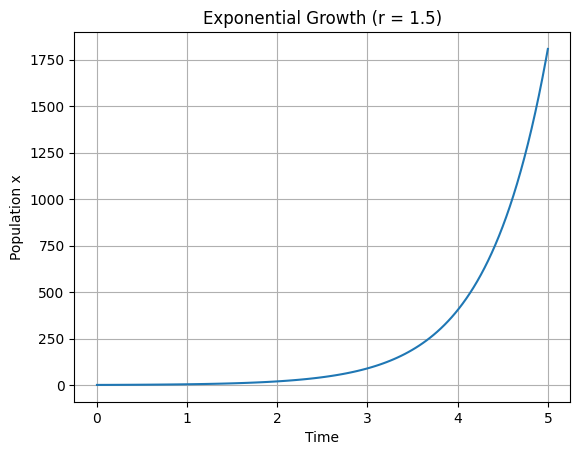

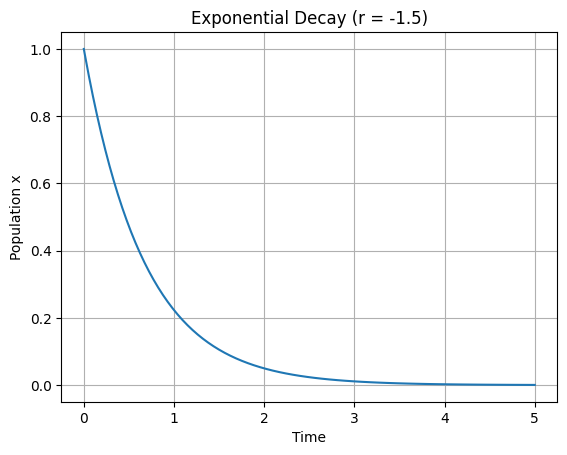

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ode import solve_ode

# Define the growth ODE: dx/dt = r*x
def growth(t, y, p):
    r = p['r']
    return np.array([r * y[0]])

# Parameters
p = {'r': 1.5}
y0 = [1.0]
t_span = (0, 5)

t, y = solve_ode(growth, t_span, y0, 'rk45', p)

plt.figure()
plt.plot(t, y[:, 0])
plt.xlabel('Time')
plt.ylabel('Population x')
plt.title('Exponential Growth (r = 1.5)')
plt.grid(True)
plt.show()

# Now try with negative r
p_neg = {'r': -1.5}
t2, y2 = solve_ode(growth, t_span, y0, 'rk45', p_neg)

plt.figure()
plt.plot(t2, y2[:, 0])
plt.xlabel('Time')
plt.ylabel('Population x')
plt.title('Exponential Decay (r = -1.5)')
plt.grid(True)
plt.show()

# With negative r, the population decays exponentially toward zero.


#### Including carrying capacity
The death rate can change if a population reaches its *carrying capacity*, or the maximum number of individuals the environment can sustain due to availability of food or other
essential resources. That is modeled as

$$
\frac{dx}{dt} = rx\left(1 - \frac{x}{K}\right).
$$

Where $K$ is the carrying capacity. You see that as $x$ approaches $K$, the fraction $\frac{x}{K}$ goes to unity, bringing the term in parenthesis to zero - no more growth in population.

Once again, let's try this with our ODE solving tools. Look closely at how much of this code is a repeat of what we just did. Try $K=15$.

### Exercise 2
Write code to solve the growth ODE numerically and plot the result.

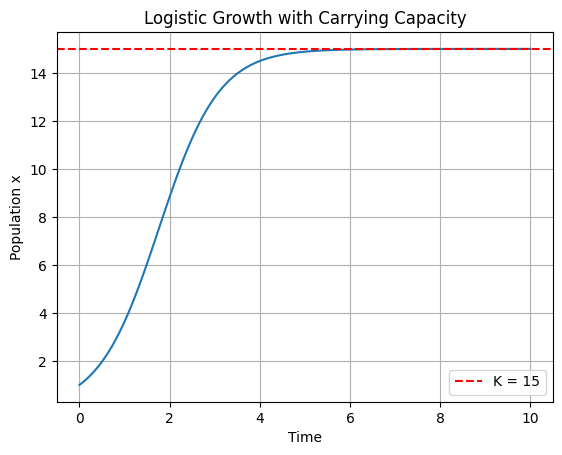

In [3]:
# Logistic growth: dx/dt = r*x*(1 - x/K)
def logistic(t, y, p):
    r = p['r']
    K = p['K']
    return np.array([r * y[0] * (1 - y[0] / K)])

p = {'r': 1.5, 'K': 15}
y0 = [1.0]
t_span = (0, 10)

t, y = solve_ode(logistic, t_span, y0, 'rk45', p)

plt.figure()
plt.plot(t, y[:, 0])
plt.axhline(y=15, color='r', linestyle='--', label='K = 15')
plt.xlabel('Time')
plt.ylabel('Population x')
plt.title('Logistic Growth with Carrying Capacity')
plt.legend()
plt.grid(True)
plt.show()


#### Lotka-Voltera

Now, generalizing the lessons for a single species to two species \(x\) and \(y\), we arrive at the Lotka-Voltera equations:

$$
\begin{eqnarray}
\frac{dx}{dt} & = \alpha x - \beta x y \\
\frac{dy}{dt} & = \delta x y  - \gamma y
\end{eqnarray}
$$

Where,

* $\alpha$ is the birth rate minus death rate of species $x$, the prey species. Note that food for the prey is implicit, it's always their and without predation the prey will grow to infinite population. Try $\alpha=.6$
* $\gamma$ is the death rate of species $y$, the predator species. Note that without explicit food, this species dies off. Try $\gamma = .5$
* $\beta$ is the success rate of the predator species in terms of how frequently they capture their prey. Try $\beta = 1.2$
* $\delta$ is the rate that the predator can convert prey into new predators; a measure of how nutrition can be converted to offspring. Try $\delta = .1$

### Exercise 3
Write code to solve the growth ODE numerically and plot the result.

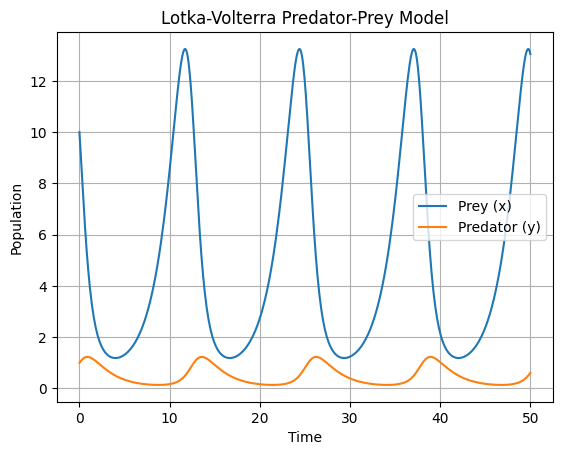

In [4]:
# Lotka-Volterra: dx/dt = alpha*x - beta*x*y
#                 dy/dt = delta*x*y - gamma*y
def lotka_volterra(t, y, p):
    x, yy = y[0], y[1]
    alpha = p['alpha']
    beta = p['beta']
    delta = p['delta']
    gamma = p['gamma']
    dxdt = alpha * x - beta * x * yy
    dydt = delta * x * yy - gamma * yy
    return np.array([dxdt, dydt])

p = {'alpha': 0.6, 'beta': 1.2, 'delta': 0.1, 'gamma': 0.5}
y0 = [10.0, 1.0]
t_span = (0, 50)

t, y = solve_ode(lotka_volterra, t_span, y0, 'rk45', p)

plt.figure()
plt.plot(t, y[:, 0], label='Prey (x)')
plt.plot(t, y[:, 1], label='Predator (y)')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Lotka-Volterra Predator-Prey Model')
plt.legend()
plt.grid(True)
plt.show()


### SIR Model

The (S)usceptible, (I)nfected, (R)ecovered model for disease dynamics. The model is stated in terms of rates of change as follows

$$
\begin{eqnarray}
\frac{dS}{dt} &=& - \frac{\beta I S}{N}\\
\frac{dI}{dt} &=& \frac{\beta I S}{N}- \gamma I\\
\frac{dR}{dt} &=& \gamma I,
\end{eqnarray}
$$

where

* $\beta$ is the rate of infection or how easy it is to spread the disease when populations come into contact. Try $\beta=2.0$
* $\gamma$ is the rate of recovery, or how long an individual is infectious. Try $\gamma = .5$
* the *products* of populations measure the interaction.
* note that the loss of members of one population results in gains for others -- individuals are conserved. There is no death in this epidemic.

For all its simplicity, extensions of this were used to model COVID-19. The biggest changes were to $\beta$ and based on knowledge of population aggregation (cities vs. rural, or schools vs. hospitals). Age structured models were also used.

### Exercise 4
Write code to solve the growth ODE numerically and plot the result.

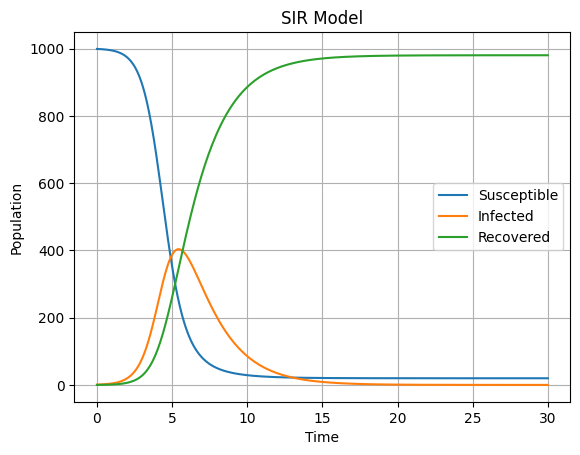

In [5]:
# SIR Model: dS/dt = -beta*I*S/N
#             dI/dt = beta*I*S/N - gamma*I
#             dR/dt = gamma*I
def sir(t, y, p):
    S, I, R = y[0], y[1], y[2]
    N = p['N']
    beta = p['beta']
    gamma = p['gamma']
    dSdt = -beta * I * S / N
    dIdt = beta * I * S / N - gamma * I
    dRdt = gamma * I
    return np.array([dSdt, dIdt, dRdt])

N = 1000
p = {'beta': 2.0, 'gamma': 0.5, 'N': N}
y0 = [N - 1, 1, 0]  # S0, I0, R0
t_span = (0, 30)

t, y = solve_ode(sir, t_span, y0, 'rk45', p)

plt.figure()
plt.plot(t, y[:, 0], label='Susceptible')
plt.plot(t, y[:, 1], label='Infected')
plt.plot(t, y[:, 2], label='Recovered')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('SIR Model')
plt.legend()
plt.grid(True)
plt.show()


### Exercise 5: Do either Zombie Apocalypse or Neanderthals

#### Zombie Apocalypse

*I ran this assignment a decade ago, when zombies were a bigger part of the popular culture. Recently, I saw "28 Years Later: The Bone Temple" and have to say, I really enjoyed it! So, let's return to thinking about zombies!*

Perhaps you are concerned by the threat posed by zombie invasions. Based on my “research”,
here are the facts that are known about zombies.

* There are two types of zombies, fed and hungry.
* Fed zombies scratch humans, turning them into fed zombies. They succeed at a rate
of 0.008 interactions per unit time.
* Hungry zombies eat human brains, and become fed zombies. The human that is eaten
does not become a zombie. Hungry zombies succeed in catching a human to eat in
0.003 interactions per unit time.
* Fed zombies become hungry zombies at a rate of 0.15 per unit time.
* Hungry zombies die at a rate of 0.3 per unit time.
* All zombie scenarios involve an initial population of 100 humans, 1 fed zombie, and 0
hungry zombies.
* 50 units of time is sufficient to see how zombie epidemics result. During this period of
time, there are no natural deaths or births in the human population.

Model the Zombie invasion.

My own research indicates that an effective means of battling the zombies is to reduce
the nutrition yielded by the brain. This can be done by assiduously maintaining the cellphone network throughout the zombie apocalypse. Test my theory by comparing the results of
the zombie invasion above to one in which the rate fed zombies become hungry is multiplied by an increasingly large factor.

#### Neanderthals

This problem is based on the paper of J. C. Flores (1998) J. theor. Biol. 191, 295-298. You may want to read it before proceeding. Produce a competition model for Early Modern Man ($E$) and Neanderthals ($N$). The equations from the paper are

$$\frac{dN}{dt} = N ( A - D (N + E) -B)$$
$$\frac{dE}{dt} = E ( A - D (N + E) -sB)$$

where A, B, D, and, s are parameters suggesting that early man and neanderthals had the same birth rates $A$, but early humans has a slightly lower death rate $B$ (I guess we're smarter and took more calculated risks?). Death is modulated by $s$ which is between 0 and 1. Both populations suffer from competition from resources as $D(N+E)$.


Assume parameters of A=1/12, B=1/35, D=1/1000, N0=50, and E0=1. Given that 0 < s < 1 and gives the
advantage conferred to modern man in terms of mortality, experiment with values of s until
you find the value that pushes Neanderthals to extinction in the 5,000 - 10,000 years observed
in the archaeological records.

Now alter the equations to instead explore the idea that the populations are identical in all ways, except neanderthals have a lower effective birth rate due to longer gestation, a longer period of child rearing, or both. Lower their birth rate by less than one percent. Does this birth rate hypothesis produce results that are less plausible than the mortality hypothesis? Which scenario is more plausible to you?


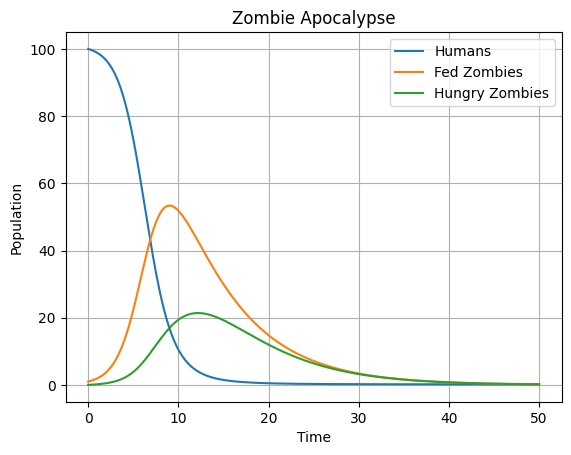

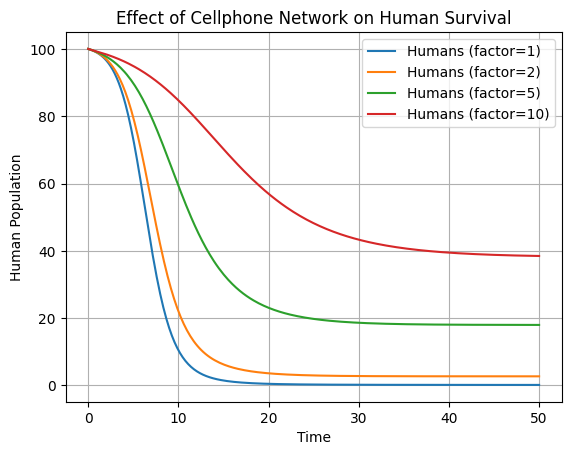

In [ ]:
# Zombie Apocalypse
# H = humans, F = fed zombies, Z = hungry zombies
# dH/dt = -0.008*F*H - 0.003*Z*H
# dF/dt = 0.008*F*H + 0.003*Z*H - 0.15*F
# dZ/dt = 0.15*F - 0.3*Z

def zombies(t, y, p):
    H, F, Z = y[0], y[1], y[2]
    a = p['a']  # fed zombie scratch rate
    b = p['b']  # hungry zombie eating rate
    c = p['c']  # fed to hungry rate
    d = p['d']  # hungry zombie death rate
    dHdt = -a * F * H - b * Z * H
    dFdt = a * F * H + b * Z * H - c * F
    dZdt = c * F - d * Z
    return np.array([dHdt, dFdt, dZdt])

p = {'a': 0.008, 'b': 0.003, 'c': 0.15, 'd': 0.3}
y0 = [100, 1, 0]  # 100 humans, 1 fed zombie, 0 hungry zombies
t_span = (0, 50)

t, y = solve_ode(zombies, t_span, y0, 'rk45', p)

plt.figure()
plt.plot(t, y[:, 0], label='Humans')
plt.plot(t, y[:, 1], label='Fed Zombies')
plt.plot(t, y[:, 2], label='Hungry Zombies')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Zombie Apocalypse')
plt.legend()
plt.grid(True)
plt.show()

# Now test the cellphone theory: multiply the fed to hungry rate by a large factor
plt.figure()
for factor in [1, 2, 5, 10]:
    p_test = {'a': 0.008, 'b': 0.003, 'c': 0.15 * factor, 'd': 0.3}
    t, y = solve_ode(zombies, t_span, y0, 'rk45', p_test)
    plt.plot(t, y[:, 0], label=f'Humans (factor={factor})')

plt.xlabel('Time')
plt.ylabel('Human Population')
plt.title('Effect of Cellphone Network on Human Survival')
plt.legend()
plt.grid(True)
plt.show()

# Increasing the factor makes fed zombies become hungry faster,
# and hungry zombies die off. This helps humans survive longer,
# supporting the cellphone theory.
